# Reprojecting and resampling

Change the coordinate reference system, or change the pixel size - the two operations that get datasets onto a common grid.

- **Data:** the bundled Sentinel-2 sample
- **Network:** only for the first download of the sample

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

# Keeps the figures stored in this notebook small; raise it for print-quality output.
plt.rcParams["figure.dpi"] = 80

In [2]:
from eeo import load_raster
from eeo.datasets import load_sample_dataset

sd = load_sample_dataset()
scene = load_raster(sd.sentinel2_stacked)

print("crs        :", scene.get_crs())
print("shape      :", scene.get_shape())
print("pixel size :", scene.get_transform().a, "m")

crs        : EPSG:32633
shape      : (1024, 1024)
pixel size : 10.0 m


## Reprojecting

`reproject_raster` warps a raster into a different CRS. The target accepts an EPSG code as an int or string, or anything pyproj understands.

In [3]:
wgs84 = scene.reproject_raster(target_crs=4326, resampling_method="bilinear")

print("crs        :", wgs84.get_crs())
print("shape      :", wgs84.get_shape(), "(changed — a warped grid rarely keeps its size)")
print("pixel size :", wgs84.get_transform().a, "degrees")
print("bounds     :", wgs84.get_bounds())

crs        : EPSG:4326
shape      : (814, 1219) (changed — a warped grid rarely keeps its size)
pixel size : 0.00011542336459177518 degrees
bounds     : BoundingBox(left=13.351292717266531, bottom=48.20354648007519, right=13.491993798703906, top=48.2975010988529)


The output is a *new* grid: warping rotates and stretches the footprint, so the result is the axis-aligned box that contains it, and the pixel count changes.  
Nothing about the input is modified.

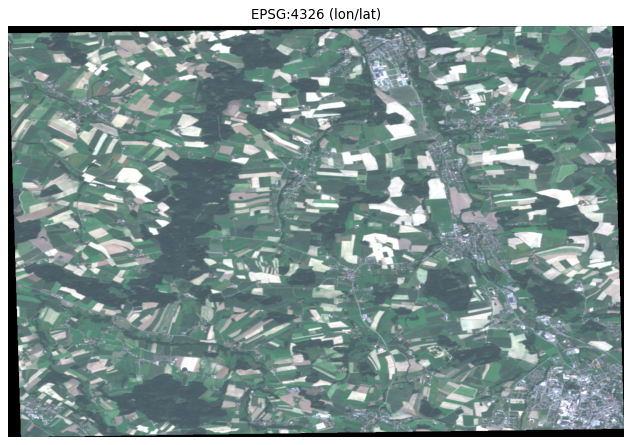

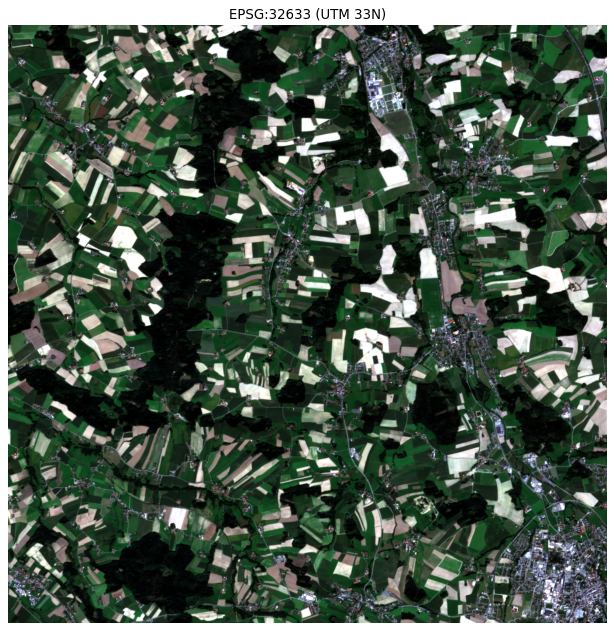

In [4]:
wgs84.plot_composite(["red", "green", "blue"], pmin=2, pmax=98, title="EPSG:4326 (lon/lat)")
scene.plot_composite(["red", "green", "blue"], pmin=2, pmax=98, title="EPSG:32633 (UTM 33N)")

### Choosing a resampling method

Warping has to invent values at the new pixel centres. The method decides how:

| method | use for |
| --- | --- |
| `"nearest"` | categorical data - land cover, masks, classifications |
| `"bilinear"` | continuous data - reflectance, elevation, indices |
| `"cubic"` | continuous data, smoother, slower |
| `"average"` | downsampling continuous data without aliasing |

`"nearest"` is the default because it is the only one that never fabricates a value that was not in the input - which is what you want for a class map, and wrong for imagery you are going to analyse.

In [5]:
import numpy as np

for method in ("nearest", "bilinear", "cubic", "average"):
    out = scene.reproject_raster(target_crs=4326, resampling_method=method)
    band = out.get_band("nir").astype("float64")
    print(f"{method:9s} shape {out.get_shape()}  mean {band.mean():10.4f}  std {band.std():9.4f}")
    out.close()

nearest   shape (814, 1219)  mean  4427.3769  std 1325.3623
bilinear  shape (814, 1219)  mean  4427.4249  std 1302.6020
cubic     shape (814, 1219)  mean  4427.4283  std 1318.3125
average   shape (814, 1219)  mean  4445.0485  std 1278.8932


The grid is identical in every case - only the values differ. The means barely move (resampling should not shift the overall brightness), but the standard deviations do: `nearest` keeps the original pixel values and so the original variance, while the interpolating methods smooth neighbouring pixels together.

### Reprojecting to another projected CRS

Anything works, not just lon/lat - here, Web Mercator, which is what a web map expects.

In [6]:
mercator = scene.reproject_raster(target_crs="EPSG:3857", resampling_method="bilinear")
print("crs        :", mercator.get_crs())
print("shape      :", mercator.get_shape())
print("pixel size :", round(mercator.get_transform().a, 2), "m")

crs        : EPSG:3857
shape      : (1046, 1043)
pixel size : 15.01 m


## Resampling

`resample` keeps the CRS and changes the pixel size. There are three ways to say what you want, and you pass exactly one of them.

### By scale factor

Values below 1 make pixels *larger* (fewer of them); above 1 makes them smaller.

In [7]:
coarse = scene.resample(scale_factor=0.25, resampling_method="average")
fine = scene.resample(scale_factor=2, resampling_method="bilinear")

print(f"original : {scene.get_shape()}  @ {scene.get_transform().a:g} m")
print(f"x0.25    : {coarse.get_shape()}  @ {coarse.get_transform().a:g} m")
print(f"x2       : {fine.get_shape()}  @ {fine.get_transform().a:g} m")

original : (1024, 1024)  @ 10 m
x0.25    : (256, 256)  @ 40 m
x2       : (2048, 2048)  @ 5 m


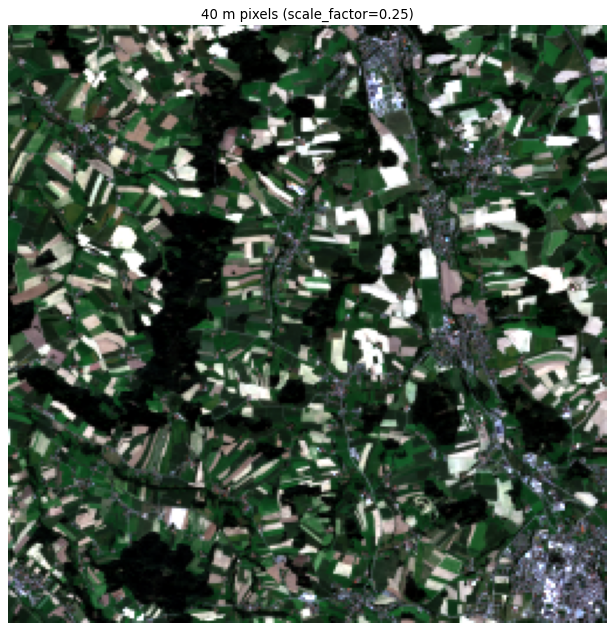

In [8]:
coarse.plot_composite(["red", "green", "blue"], pmin=2, pmax=98, title="40 m pixels (scale_factor=0.25)")

### By target resolution

Usually the clearest way to ask, because it says what you actually want: "put this on a 20 m grid".

In [9]:
twenty_metre = scene.resample(resolution=(20, 20), resampling_method="average")

print("shape      :", twenty_metre.get_shape())
print("pixel size :", twenty_metre.get_transform().a, "m")

shape      : (512, 512)
pixel size : 20.0 m


### By output size

When something downstream demands an exact pixel count.

shape: (256, 256)


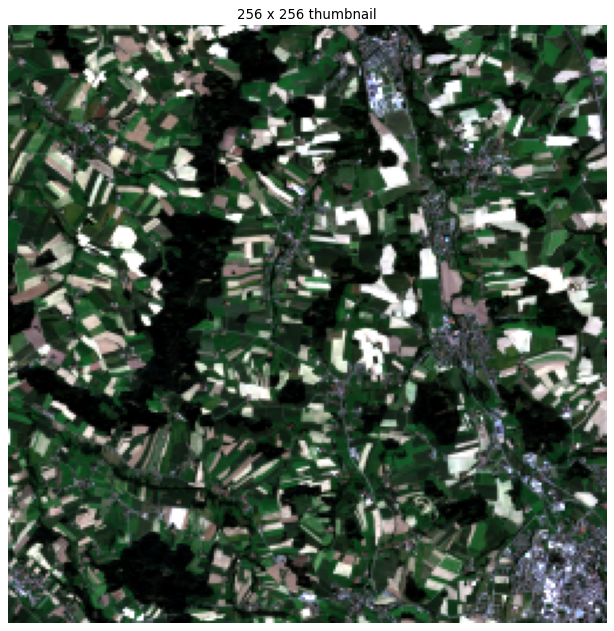

In [10]:
thumbnail = scene.resample(size=(256, 256), resampling_method="average")
print("shape:", thumbnail.get_shape())
thumbnail.plot_composite(["red", "green", "blue"], pmin=2, pmax=98, title="256 x 256 thumbnail")

### Downsampling: use `average`, not `nearest`

When you make pixels bigger, each output pixel covers many input pixels. `nearest` picks one of them and throws the rest away, which is noisy; `average` uses all of them. The difference shows up in the statistics.

In [11]:
for method in ("nearest", "average", "bilinear"):
    out = scene.resample(scale_factor=0.1, resampling_method=method)
    band = out.get_band("nir").astype("float32")
    print(f"{method:9s} mean {np.nanmean(band):8.1f}   std {np.nanstd(band):7.1f}")
    out.close()

full = scene.get_band("nir").astype("float32")
print(f"{'original':9s} mean {np.nanmean(full):8.1f}   std {np.nanstd(full):7.1f}")

nearest   mean   4605.1   std  1006.8
average   mean   4606.8   std   762.3
bilinear  mean   4606.6   std   705.9
original  mean   4606.8   std  1000.3


`average` tracks the original mean and, as expected, reduces the variance - `nearest` just subsamples.

## Getting two rasters onto one grid

This is what these operations are usually *for*. Most Easy-EO operations do it automatically: pass a dataset on a different grid to an algebra or index method and it is aligned onto the receiver's grid (`auto_align=True`, the default). Pass `auto_align=False` to demand an exact match instead.

When you want to control the alignment yourself, reproject and then resample:

In [12]:
dem = load_raster(sd.copernicus_dem)

# the DEM already shares the scene's grid, so put it somewhere else first
elsewhere = dem.reproject_raster(target_crs=4326, resampling_method="bilinear")
print("dem, moved  :", elsewhere.get_crs(), elsewhere.get_shape())

back = elsewhere.reproject_raster(
    target_crs=scene.get_crs().to_epsg(), resampling_method="bilinear"
)
aligned = back.resample(size=scene.get_shape()[::-1], resampling_method="bilinear")
print("realigned   :", aligned.get_crs(), aligned.get_shape())
print("scene       :", scene.get_crs(), scene.get_shape())

dem, moved  : EPSG:4326 (814, 1219)
realigned   : EPSG:32633 (1024, 1024)
scene       : EPSG:32633 (1024, 1024)


Note that a reproject-and-back round trip is **lossy** - every warp resamples. Reproject once, from the original, rather than chaining warps.

In [13]:
for ds in (scene, wgs84, mercator, coarse, fine, twenty_metre, thumbnail, dem, elsewhere, back, aligned):
    ds.close()
print("closed")

closed


## Next

- **[04_band_algebra_and_indices](04_band_algebra_and_indices.ipynb)** - arithmetic on bands, and the index library